# VOIS AICTE Major Project: Seasonal Agriculture Performance Analysis

Student: Iqra Siddiqui
College: Sophia College For Women
Project: Seasonal Agriculture Performance Analysis
Platform: Google Colab

### Project Purpose

This project analyzes the supplied agricultural dataset to identify
seasonal patterns, trends, relationships, group differences,
unusual observations and evidence-based recommendations.

The project includes data exploration, data cleaning, seasonal
comparison, environmental and resource analysis, economic analysis,
statistical testing, visualization and interpretation.

# Problem Statement :
Agricultural activities are influenced by seasonal variations in environmental conditions,
farming practices, resource availability and market conditions. As a result, agricultural
performance may differ from one season to another.
However, raw agricultural data does not clearly explain how agricultural performance changes
across seasons or what patterns can be observed in different seasonal conditions.
The problem is to analyze the given agricultural dataset and investigate seasonal differences
in agricultural performance by identifying meaningful patterns, trends, relationships and
variations within the available data.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

pd.set_option('display.max_columns', None)

sns.set_theme(style='whitegrid')

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load the Dataset

The supplied agricultural dataset is loaded into a Pandas DataFrame
for exploration and analysis.

In [35]:
from google.colab import files

uploaded = files.upload()

file_name = next(iter(uploaded))

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset.csv
Dataset loaded successfully!
Dataset shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 3. Dataset Overview

The first step of data analysis is to understand the structure,
size and characteristics of the dataset.

In [69]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

Number of Rows: 4000
Number of Columns: 28

Column Names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [70]:
display(df.head())

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [72]:
display(df.describe())

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,186.036000,5.070935,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,60.260583,1.978879,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,40.000000,0.500000,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,143.975000,3.690000,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,186.250000,5.120000,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,227.200000,6.400000,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,400.000000,12.080000,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [73]:
print(df.dtypes)

Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        int64
Profit_INR      

## 4. Initial Dataset Inspection

The dataset is examined to understand its size, data types,
duplicate records, missing values and categorical variables.

In [36]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nMissing values:")
display(
    df.isna().sum()
    .sort_values(ascending=False)
    .to_frame("Missing Count")
)

print("\nCategorical variables:")

for col in df.select_dtypes(include='object').columns:
    print(
        f"{col}: {df[col].nunique()} unique values"
    )

Number of rows: 4000
Number of columns: 28

Column names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Data types:


,Data Type
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64



Duplicate rows: 0

Missing values:


,Missing Count
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32
Farm_ID,0
Crop,0
District,0
Farm_Area_Hectares,0
Season,0
Avg_Temperature_C,0
Humidity_pct,0



Categorical variables:
Farm_ID: 4000 unique values
State: 8 unique values
District: 10 unique values
Crop: 8 unique values
Season: 3 unique values
Irrigation_Method: 4 unique values


## 5. Data Cleaning and Preparation

Missing values in important numerical variables are handled using
median imputation.

Median imputation is used because it is less affected by extreme
values than mean imputation.

A separate cleaned copy of the original dataset is created so that
the original data remains unchanged.

In [37]:
df_clean = df.copy()

numeric_impute_cols = [
    'Rainfall_mm',
    'Soil_Moisture_pct',
    'Yield_Tonnes_Ha'
]

for col in numeric_impute_cols:
    df_clean[col] = df_clean[col].fillna(
        df_clean[col].median()
    )

print("Missing values after cleaning:")

display(
    df_clean.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("Missing Count")
    .head(10)
)

print(
    "Duplicate rows after cleaning:",
    df_clean.duplicated().sum()
)

Missing values after cleaning:


,Missing Count
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


Duplicate rows after cleaning: 0


## 6. Descriptive Statistics

Descriptive statistics are calculated to understand the central
tendency, spread and range of numerical variables.

In [38]:
display(
    df_clean.describe()
    .T
    .round(2)
)

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.89,4.22,0.50,4.26,7.90,11.65,15.00
Rainfall_mm,4000.0,600.92,287.19,80.00,371.58,582.00,831.98,1395.20
Avg_Temperature_C,4000.0,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,4000.0,63.21,11.96,25.00,54.78,63.00,71.90,95.00
Sunlight_Hours_Day,4000.0,7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,4000.0,6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,4000.0,26.51,6.68,8.00,21.80,26.40,31.20,47.00
Nitrogen_kg_ha,4000.0,120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,4000.0,57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,4000.0,104.76,27.74,30.00,86.20,105.10,123.60,200.00


## 7. Key Analytical Questions

1. How does agricultural performance vary across seasons?

2. What major seasonal patterns can be observed?

3. Which environmental characteristics change between seasons?

4. Are resource-use patterns different between seasons?

5. How do economic outcomes vary across seasons?

6. Do irrigation methods show different yield and profit outcomes?

7. Are there relationships between yield, production, water
   efficiency, revenue and profit?

8. Are there unusual observations that should be investigated?

9. Are seasonal patterns consistent across crops?

10. What recommendations are supported by the observed data?

## 8. Overall Seasonal Performance

The major agricultural, economic, environmental and resource
indicators are summarized by season.

In [39]:
season_summary = df_clean.groupby('Season').agg(

    Farms=('Farm_ID', 'count'),

    Avg_Yield_Tonnes_Ha=(
        'Yield_Tonnes_Ha',
        'mean'
    ),

    Avg_Production_Tonnes=(
        'Production_Tonnes',
        'mean'
    ),

    Avg_Revenue_INR=(
        'Revenue_INR',
        'mean'
    ),

    Avg_Cost_INR=(
        'Total_Cost_INR',
        'mean'
    ),

    Avg_Profit_INR=(
        'Profit_INR',
        'mean'
    ),

    Profitability_Rate_pct=(
        'Profit_INR',
        lambda x: (x > 0).mean() * 100
    ),

    Avg_Water_Used_m3=(
        'Water_Used_m3',
        'mean'
    ),

    Avg_Water_Efficiency=(
        'Water_Efficiency_t_per_1000m3',
        'mean'
    ),

    Avg_Disease_Pest_Risk_pct=(
        'Disease_Pest_Risk_pct',
        'mean'
    ),

    Avg_Rainfall_mm=(
        'Rainfall_mm',
        'mean'
    ),

    Avg_Temperature_C=(
        'Avg_Temperature_C',
        'mean'
    )

).round(2)

display(season_summary)

,Farms,Avg_Yield_Tonnes_Ha,Avg_Production_Tonnes,Avg_Revenue_INR,Avg_Cost_INR,Avg_Profit_INR,Profitability_Rate_pct,Avg_Water_Used_m3,Avg_Water_Efficiency,Avg_Disease_Pest_Risk_pct,Avg_Rainfall_mm,Avg_Temperature_C
Season,,,,,,,,,,,,
Kharif,1779,5.63,46.31,710719.06,531804.41,178914.65,57.79,6102.20,5.89,54.47,849.20,28.45
Rabi,1627,5.04,41.49,601526.05,513836.58,87689.47,48.86,5846.99,5.19,40.48,437.62,23.49
Zaid,594,4.64,38.89,519171.90,543976.73,-24804.82,35.52,6419.89,4.41,38.22,304.65,31.04


## 9. Seasonal Yield Analysis

The average crop yield is compared across Kharif, Rabi and Zaid
seasons to identify differences in agricultural productivity.

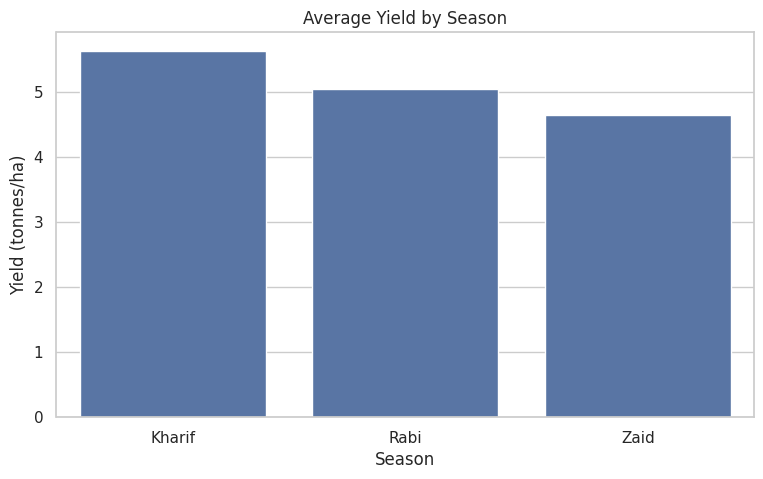

In [40]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=df_clean,
    x='Season',
    y='Yield_Tonnes_Ha',
    estimator='mean',
    errorbar=None
)

plt.title('Average Yield by Season')
plt.xlabel('Season')
plt.ylabel('Yield (tonnes/ha)')

plt.show()

## 10. Seasonal Profit Analysis

Average profit is compared across seasons to understand differences
in economic performance.

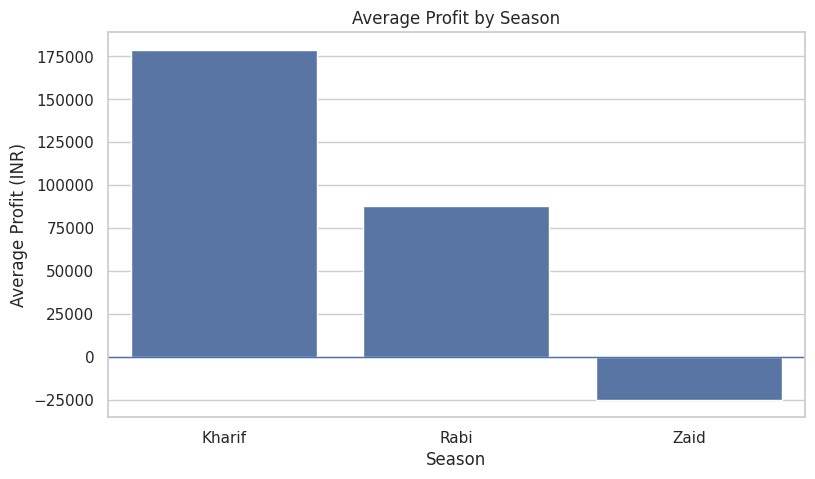

In [41]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=df_clean,
    x='Season',
    y='Profit_INR',
    estimator='mean',
    errorbar=None
)

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')

plt.axhline(0, linewidth=1)

plt.show()

## 11. Seasonal Environmental Comparison

Environmental characteristics such as rainfall, temperature,
humidity, soil moisture and disease/pest risk are compared across
seasons.

In [42]:
env = df_clean.groupby('Season')[
    [
        'Rainfall_mm',
        'Avg_Temperature_C',
        'Humidity_pct',
        'Soil_Moisture_pct',
        'Disease_Pest_Risk_pct'
    ]
].mean().round(2)

display(env)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Disease_Pest_Risk_pct
Season,,,,,
Kharif,849.20,28.45,71.81,31.15,54.47
Rabi,437.62,23.49,57.89,24.07,40.48
Zaid,304.65,31.04,52.01,19.28,38.22


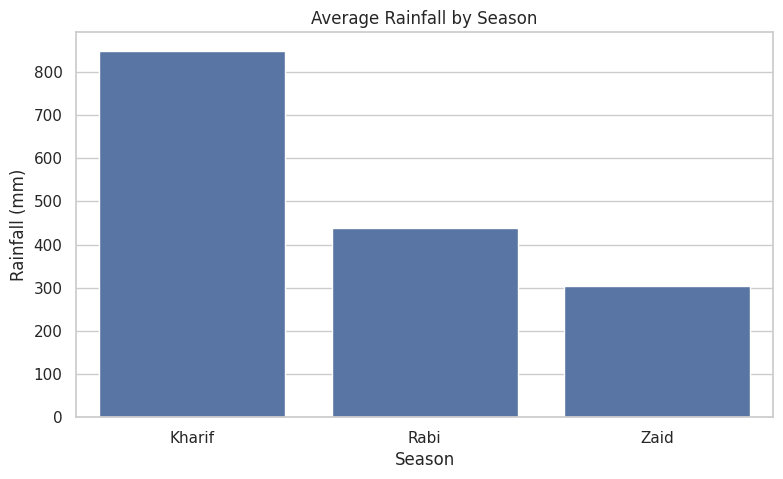

In [43]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=df_clean,
    x='Season',
    y='Rainfall_mm',
    estimator='mean',
    errorbar=None
)

plt.title('Average Rainfall by Season')
plt.xlabel('Season')
plt.ylabel('Rainfall (mm)')

plt.show()

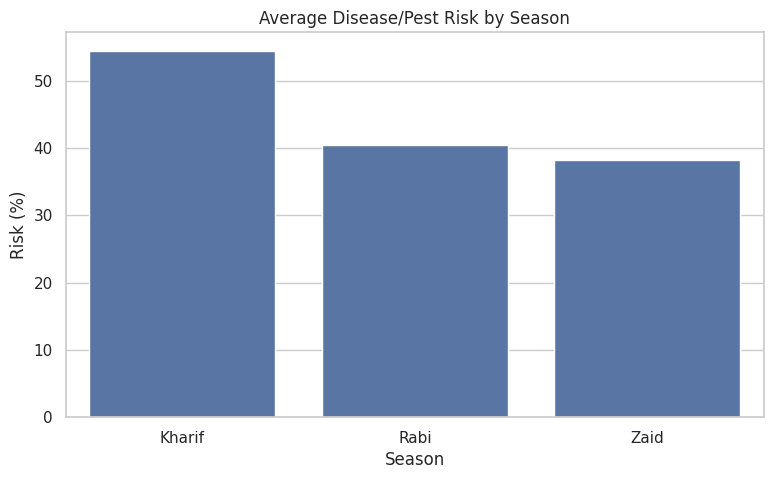

In [44]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=df_clean,
    x='Season',
    y='Disease_Pest_Risk_pct',
    estimator='mean',
    errorbar=None
)

plt.title('Average Disease/Pest Risk by Season')
plt.xlabel('Season')
plt.ylabel('Risk (%)')

plt.show()

## 12. Resource Use and Efficiency

Water, fertilizer, pesticide use and water efficiency are compared
across seasons.

This helps determine whether resource-use patterns differ between
Kharif, Rabi and Zaid.

In [45]:
resource = df_clean.groupby('Season')[
    [
        'Water_Used_m3',
        'Water_Efficiency_t_per_1000m3',
        'Fertilizer_kg_ha',
        'Pesticide_Litre_ha'
    ]
].mean().round(2)

display(resource)

,Water_Used_m3,Water_Efficiency_t_per_1000m3,Fertilizer_kg_ha,Pesticide_Litre_ha
Season,,,,
Kharif,6102.20,5.89,187.08,5.08
Rabi,5846.99,5.19,185.41,5.02
Zaid,6419.89,4.41,184.64,5.17


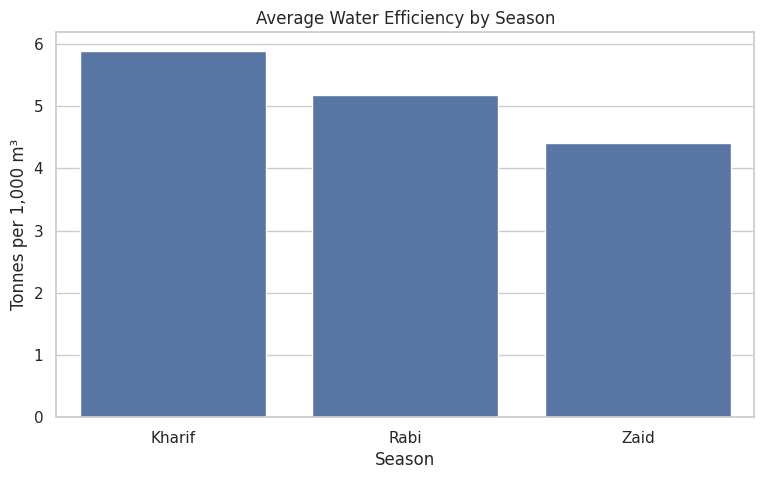

In [46]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=df_clean,
    x='Season',
    y='Water_Efficiency_t_per_1000m3',
    estimator='mean',
    errorbar=None
)

plt.title('Average Water Efficiency by Season')
plt.xlabel('Season')
plt.ylabel('Tonnes per 1,000 m³')

plt.show()

## 13. Irrigation Method Comparison

Different irrigation methods are compared using yield, profit,
water usage, water efficiency and disease/pest risk.

The results show associations in the dataset and should not be
interpreted as proof of causation.

In [47]:
irrigation_summary = df_clean.groupby(
    'Irrigation_Method'
).agg(

    Avg_Yield=(
        'Yield_Tonnes_Ha',
        'mean'
    ),

    Avg_Profit=(
        'Profit_INR',
        'mean'
    ),

    Avg_Water=(
        'Water_Used_m3',
        'mean'
    ),

    Avg_Water_Efficiency=(
        'Water_Efficiency_t_per_1000m3',
        'mean'
    ),

    Avg_Risk=(
        'Disease_Pest_Risk_pct',
        'mean'
    )

).round(2)

display(irrigation_summary)

,Avg_Yield,Avg_Profit,Avg_Water,Avg_Water_Efficiency,Avg_Risk
Irrigation_Method,,,,,
Drip,6.58,219626.00,5918.75,6.27,45.79
Flood,4.86,73354.02,8026.47,3.44,46.60
Rainfed,4.60,79050.37,3549.55,7.56,46.49
Sprinkler,5.16,91121.08,6208.26,4.67,46.48


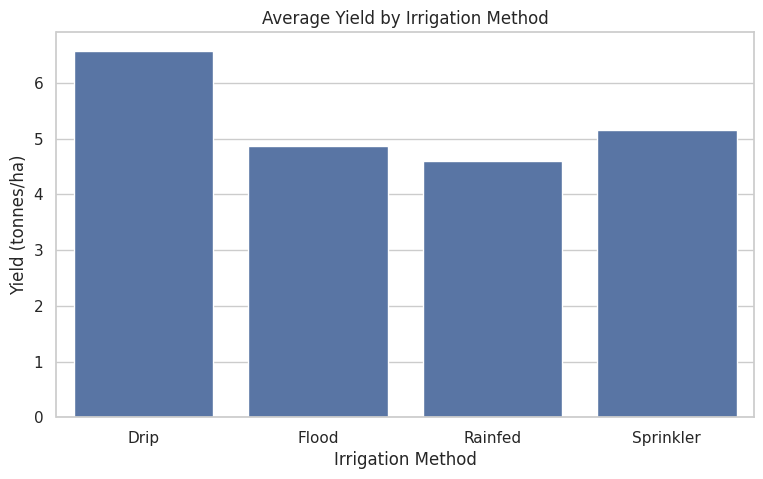

In [48]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=df_clean,
    x='Irrigation_Method',
    y='Yield_Tonnes_Ha',
    estimator='mean',
    errorbar=None
)

plt.title('Average Yield by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Yield (tonnes/ha)')

plt.show()

## 14. Crop-wise Performance Analysis

Crop-wise yield, production, revenue and profit are compared to
identify differences in agricultural and economic performance.

In [49]:
crop_summary = df_clean.groupby('Crop').agg(

    Farms=(
        'Farm_ID',
        'count'
    ),

    Avg_Yield=(
        'Yield_Tonnes_Ha',
        'mean'
    ),

    Avg_Production=(
        'Production_Tonnes',
        'mean'
    ),

    Avg_Revenue=(
        'Revenue_INR',
        'mean'
    ),

    Avg_Profit=(
        'Profit_INR',
        'mean'
    )

).sort_values(
    'Avg_Profit',
    ascending=False
).round(2)

display(crop_summary)

,Farms,Avg_Yield,Avg_Production,Avg_Revenue,Avg_Profit
Crop,,,,,
Sugarcane,305,46.64,392.41,1371980.11,817187.99
Chilli,412,1.54,12.38,1276777.23,750878.34
Cotton,508,1.23,9.40,639423.08,124546.92
Groundnut,424,1.32,9.66,542935.50,44858.12
Pulses,496,0.92,7.40,528465.87,-4238.05
Maize,551,2.71,21.78,457067.99,-83978.33
Rice,690,2.43,19.29,423615.26,-102213.50
Wheat,614,2.11,16.85,400104.89,-123398.34


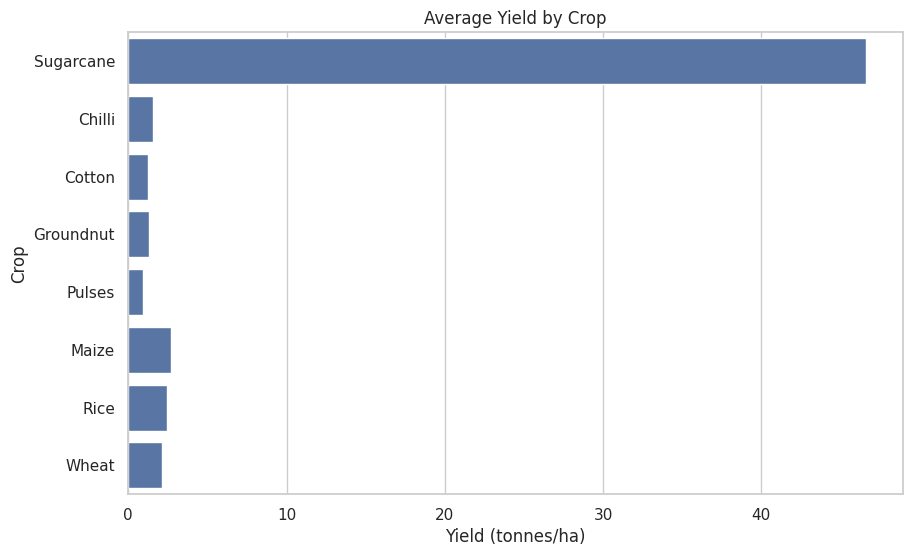

In [50]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=crop_summary.reset_index(),
    y='Crop',
    x='Avg_Yield',
    errorbar=None
)

plt.title('Average Yield by Crop')
plt.xlabel('Yield (tonnes/ha)')
plt.ylabel('Crop')

plt.show()

## 15. Crop and Season Comparison

The interaction between crop and season is analyzed to determine
whether crop performance changes across different seasons.

In [51]:
crop_season_yield = pd.pivot_table(
    df_clean,
    index='Crop',
    columns='Season',
    values='Yield_Tonnes_Ha',
    aggfunc='mean'
).round(2)

display(crop_season_yield)

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


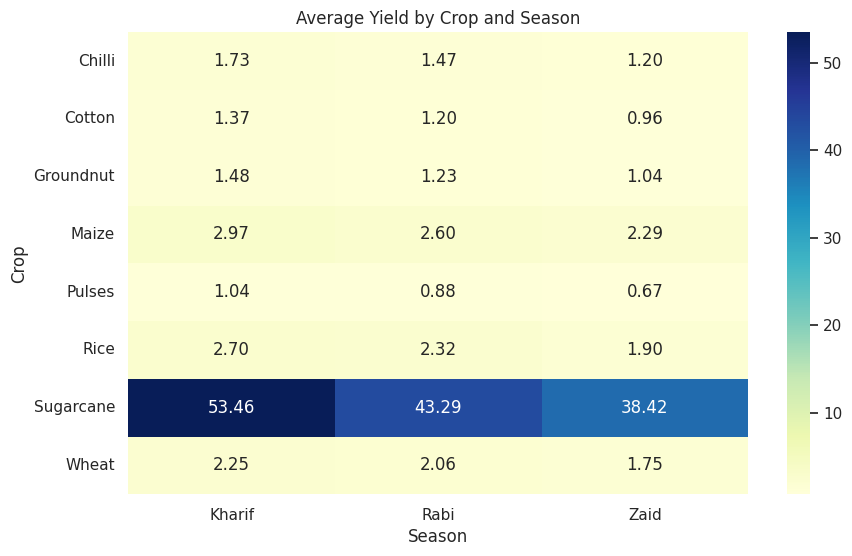

In [52]:
plt.figure(figsize=(10,6))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Average Yield by Crop and Season')
plt.xlabel('Season')
plt.ylabel('Crop')

plt.show()

## 16. Regional / State Performance Analysis

Agricultural yield and profitability are compared across states
to identify regional differences.

In [53]:
state_summary = df_clean.groupby('State').agg(

    Avg_Yield=(
        'Yield_Tonnes_Ha',
        'mean'
    ),

    Avg_Profit=(
        'Profit_INR',
        'mean'
    ),

    Profitability_Rate=(
        'Profit_INR',
        lambda x: (x > 0).mean() * 100
    )

).sort_values(
    'Avg_Profit',
    ascending=False
).round(2)

display(state_summary)

,Avg_Yield,Avg_Profit,Profitability_Rate
State,,,
Punjab,6.12,136025.64,52.27
Maharashtra,5.02,135428.86,50.00
Karnataka,5.69,119422.34,52.56
Tamil Nadu,4.88,117744.75,49.28
Gujarat,5.66,117568.24,50.61
Telangana,5.04,108829.62,54.84
Madhya Pradesh,4.99,86840.76,48.89
Andhra Pradesh,4.63,73453.53,48.39


## 17. Relationship Analysis

Correlation analysis is used to examine relationships between
important agricultural and economic variables.

Correlation indicates association and does not prove causation.

In [54]:
key_cols = [
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Revenue_INR',
    'Profit_INR',
    'Water_Efficiency_t_per_1000m3',
    'Market_Price_INR_Tonne',
    'Water_Used_m3'
]

corr = df_clean[key_cols].corr().round(3)

display(corr)

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Water_Efficiency_t_per_1000m3,Market_Price_INR_Tonne,Water_Used_m3
Yield_Tonnes_Ha,1.000,0.883,0.432,0.488,0.913,-0.383,0.386
Production_Tonnes,0.883,1.000,0.564,0.554,0.812,-0.338,0.516
Revenue_INR,0.432,0.564,1.000,0.887,0.428,0.182,0.429
Profit_INR,0.488,0.554,0.887,1.000,0.489,0.225,0.190
Water_Efficiency_t_per_1000m3,0.913,0.812,0.428,0.489,1.000,-0.373,0.217
Market_Price_INR_Tonne,-0.383,-0.338,0.182,0.225,-0.373,1.000,-0.337
Water_Used_m3,0.386,0.516,0.429,0.190,0.217,-0.337,1.000


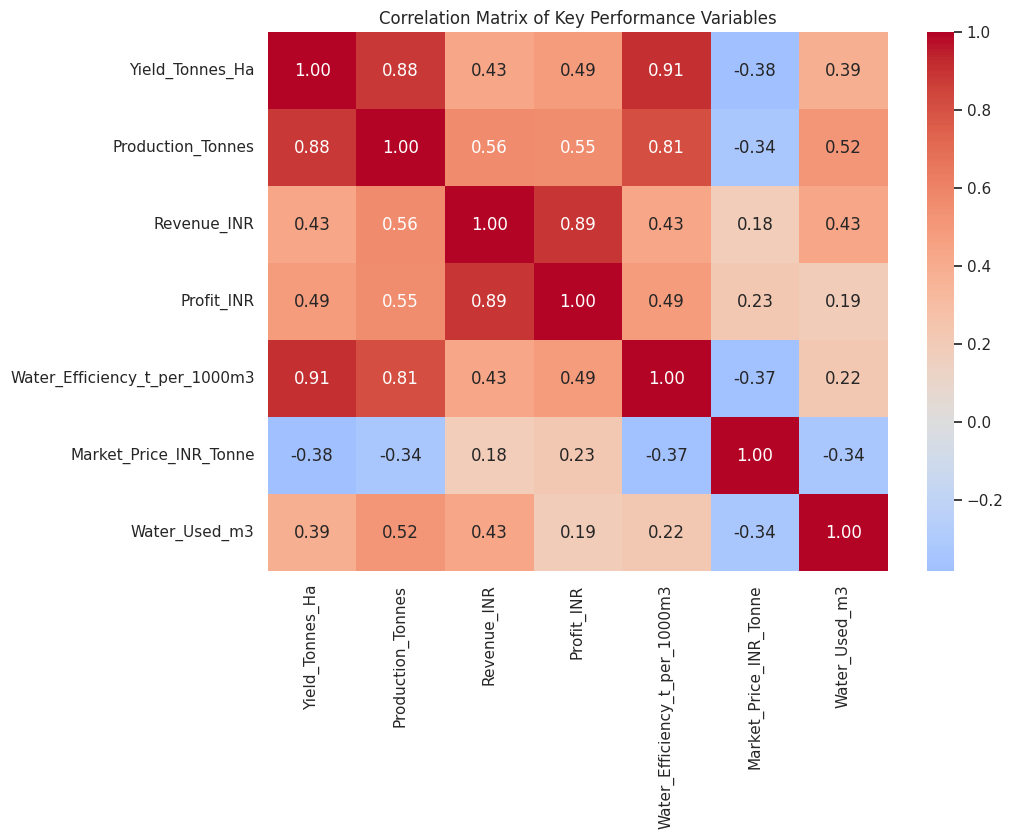

In [55]:
plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Key Performance Variables')

plt.show()

## 18. Yield vs Profit

The relationship between crop yield and profit is visualized using
a scatter plot.

The analysis also calculates the correlation between yield and
profit and between yield and water efficiency.

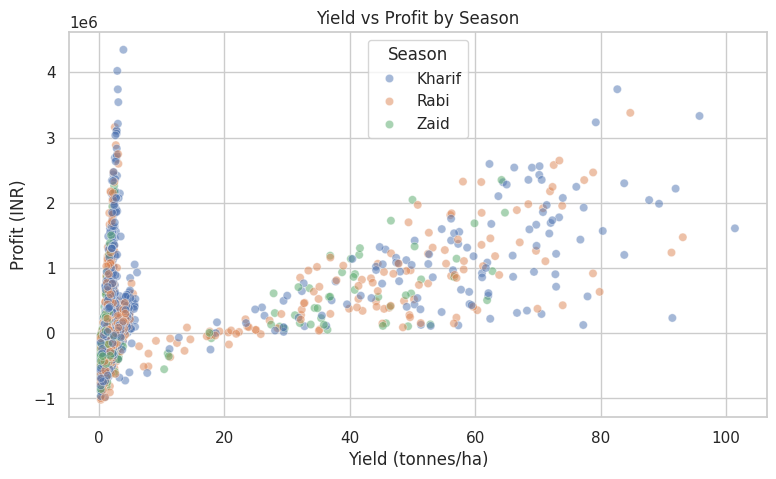

In [56]:
plt.figure(figsize=(9,5))

sns.scatterplot(
    data=df_clean,
    x='Yield_Tonnes_Ha',
    y='Profit_INR',
    hue='Season',
    alpha=0.5
)

plt.title('Yield vs Profit by Season')
plt.xlabel('Yield (tonnes/ha)')
plt.ylabel('Profit (INR)')

plt.show()

In [57]:
print(
    "Correlation: Yield vs Profit =",
    round(
        df_clean[
            'Yield_Tonnes_Ha'
        ].corr(
            df_clean['Profit_INR']
        ),
        3
    )
)

print(
    "Correlation: Yield vs Water Efficiency =",
    round(
        df_clean[
            'Yield_Tonnes_Ha'
        ].corr(
            df_clean[
                'Water_Efficiency_t_per_1000m3'
            ]
        ),
        3
    )
)

Correlation: Yield vs Profit = 0.488
Correlation: Yield vs Water Efficiency = 0.913


## 19. Statistical Testing

### One-way ANOVA

One-way ANOVA is used to test whether the mean outcome differs
across seasons or irrigation methods.

Null Hypothesis (H0):
The group means are equal.

Alternative Hypothesis (H1):
At least one group mean is different.

A p-value below 0.05 is treated as statistically significant
for this exploratory analysis.

Statistical significance does not establish causality.

In [59]:
# ============================================================
# 19A. ANOVA ACROSS SEASONS
# ============================================================

for metric in [
    'Yield_Tonnes_Ha',
    'Profit_INR',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3'
]:

    groups = [
        g[metric].values
        for _, g in df_clean.groupby('Season')
    ]

    result = stats.f_oneway(*groups)

    print(
        f"{metric}: "
        f"F={result.statistic:.3f}, "
        f"p={result.pvalue:.6g}"
    )

Yield_Tonnes_Ha: F=1.544, p=0.213678
Profit_INR: F=34.292, p=1.71242e-15
Water_Used_m3: F=2.467, p=0.0850087
Water_Efficiency_t_per_1000m3: F=6.948, p=0.000971938


In [60]:
# ============================================================
# 19B. ANOVA ACROSS IRRIGATION METHODS
# ============================================================

for metric in [
    'Yield_Tonnes_Ha',
    'Profit_INR',
    'Water_Efficiency_t_per_1000m3'
]:

    groups = [
        g[metric].values
        for _, g in df_clean.groupby(
            'Irrigation_Method'
        )
    ]

    result = stats.f_oneway(*groups)

    print(
        f"{metric}: "
        f"F={result.statistic:.3f}, "
        f"p={result.pvalue:.6g}"
    )

Yield_Tonnes_Ha: F=4.246, p=0.00528793
Profit_INR: F=15.887, p=2.87699e-10
Water_Efficiency_t_per_1000m3: F=48.576, p=7.90716e-31


## 20. Outlier / Unusual Pattern Analysis

Potential outliers are investigated using the IQR method.

An extreme observation is not automatically deleted. It may be a
legitimate observation or may require further investigation.

The crop distribution is also considered because some crops may
naturally have much higher yield values than others.

In [61]:
q1 = df_clean[
    'Yield_Tonnes_Ha'
].quantile(0.25)

q3 = df_clean[
    'Yield_Tonnes_Ha'
].quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df_clean[
    (df_clean['Yield_Tonnes_Ha'] < lower) |
    (df_clean['Yield_Tonnes_Ha'] > upper)
]

print("Q1:", round(q1, 2))
print("Q3:", round(q3, 2))
print("IQR:", round(iqr, 2))

print(
    "IQR lower bound:",
    round(lower, 2)
)

print(
    "IQR upper bound:",
    round(upper, 2)
)

print(
    "Number of yield outliers:",
    len(outliers)
)

display(
    outliers[
        [
            'Farm_ID',
            'State',
            'Crop',
            'Season',
            'Yield_Tonnes_Ha',
            'Production_Tonnes',
            'Profit_INR'
        ]
    ]
    .sort_values(
        'Yield_Tonnes_Ha',
        ascending=False
    )
    .head(15)
)

Q1: 1.05
Q3: 2.83
IQR: 1.78
IQR lower bound: -1.62
IQR upper bound: 5.5
Number of yield outliers: 302


,Farm_ID,State,Crop,Season,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR
1715,SF11716,Gujarat,Sugarcane,Kharif,101.44,641.10,1608291
3423,SF13424,Andhra Pradesh,Sugarcane,Kharif,95.79,1424.40,3330582
3525,SF13526,Andhra Pradesh,Sugarcane,Rabi,93.13,648.18,1471529
1464,SF11465,Gujarat,Sugarcane,Kharif,91.98,703.65,2216708
3523,SF13524,Karnataka,Sugarcane,Kharif,91.46,75.00,234320
2782,SF12783,Gujarat,Sugarcane,Rabi,91.32,522.35,1236801
644,SF10645,Andhra Pradesh,Sugarcane,Kharif,89.34,668.26,1984818
2847,SF12848,Telangana,Sugarcane,Kharif,87.76,672.24,2041678
357,SF10358,Punjab,Sugarcane,Rabi,84.75,1249.21,3378879
1178,SF11179,Karnataka,Sugarcane,Kharif,83.79,534.58,1200815


## 21. Crop-Specific Outlier Investigation

Very high yield observations are investigated by comparing
Sugarcane with the other crops.

This helps determine whether the overall yield distribution is
being influenced by crop composition rather than data-entry errors.

In [62]:
sugar_mean = df_clean.loc[
    df_clean['Crop'] == 'Sugarcane',
    'Yield_Tonnes_Ha'
].mean()

other_mean = df_clean.loc[
    df_clean['Crop'] != 'Sugarcane',
    'Yield_Tonnes_Ha'
].mean()

print(
    f"Average Sugarcane yield: "
    f"{sugar_mean:.2f} tonnes/ha"
)

print(
    f"Average yield of other crops: "
    f"{other_mean:.2f} tonnes/ha"
)

Average Sugarcane yield: 46.64 tonnes/ha
Average yield of other crops: 1.83 tonnes/ha


## 22. Optional Predictive Extension

A Random Forest model is used as an optional predictive extension
to estimate profit from the available farm, environmental,
resource, crop, season and market variables.

This model is a predictive baseline and should not be interpreted
as a causal agricultural decision-making system.

In [63]:
target = 'Profit_INR'

X = df_clean.drop(
    columns=[
        target,
        'Farm_ID'
    ]
)

y = df_clean[target]

categorical_cols = X.select_dtypes(
    include='object'
).columns.tolist()

numeric_cols = X.select_dtypes(
    exclude='object'
).columns.tolist()

preprocessor = ColumnTransformer([
    (
        'num',
        'passthrough',
        numeric_cols
    ),
    (
        'cat',
        OneHotEncoder(
            handle_unknown='ignore'
        ),
        categorical_cols
    )
])

model = Pipeline([
    (
        'prep',
        preprocessor
    ),
    (
        'rf',
        RandomForestRegressor(
            n_estimators=250,
            random_state=42,
            n_jobs=-1,
            max_depth=None
        )
    )
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

pred = model.predict(X_test)

print(
    "Mean Absolute Error:",
    round(
        mean_absolute_error(
            y_test,
            pred
        ),
        2
    )
)

print(
    "R² Score:",
    round(
        r2_score(
            y_test,
            pred
        ),
        3
    )
)

Mean Absolute Error: 13743.25
R² Score: 0.998


## 23. Evidence-Based Findings

Based on the supplied dataset:

1. Kharif has the highest average yield, average revenue, average
   profit and profitability rate among the three seasons.

2. Zaid has the lowest average yield and is the only season with
   negative average profit.

3. Kharif has the highest average rainfall and disease/pest risk
   in this dataset.

4. Drip irrigation has the highest average yield and average profit
   among the irrigation methods.

5. Rainfed farming has the highest average water-efficiency
   metric, while its average yield is lower than Drip.

6. Sugarcane has exceptionally high yield compared with the other
   crops, so overall yield averages should be interpreted with
   crop mix in mind.

7. Profit is strongly associated with revenue, while yield and
   production also show positive associations with profit.

8. The seasonal difference in average profit is statistically
   significant according to the one-way ANOVA, while the
   difference in raw average yield is not statistically significant
   at the 5% level.

## 24. Recommendations

1. Use season-specific agricultural planning for Kharif, Rabi
   and Zaid.

2. Evaluate profitability rather than relying on yield alone.

3. Investigate irrigation practices because Drip shows strong
   average yield/profit performance while Rainfed shows high
   water efficiency.

4. Compare crops using crop-specific benchmarks.

5. Monitor disease and pest risk during high-risk seasons.

6. Investigate the economic performance of Zaid in greater detail.

7. Validate unusual high-yield observations for crop-specific
   units and possible data-entry inconsistencies.

8. Use larger and multi-year datasets in future studies for more
   reliable conclusions.

## 25. Export Cleaned Data and Summary Tables

The cleaned dataset and important summary tables are exported as
CSV files for documentation and future use.

In [64]:
df_clean.to_csv(
    'seasonal_agriculture_performance_cleaned.csv',
    index=False
)

season_summary.to_csv(
    'season_summary.csv'
)

crop_summary.to_csv(
    'crop_summary.csv'
)

state_summary.to_csv(
    'state_summary.csv'
)

irrigation_summary.to_csv(
    'irrigation_summary.csv'
)

print(
    "Cleaned dataset and summary tables exported successfully!"
)

Cleaned dataset and summary tables exported successfully!


## 26. Conclusion

The analysis demonstrates that seasonal agricultural performance
varies across economic, environmental and resource dimensions.

Kharif shows the strongest average economic performance, while
Zaid shows weaker economic performance in the supplied dataset.

Irrigation methods also differ in observed yield and profit
outcomes, while water efficiency shows meaningful relationships
with agricultural performance.

The analysis combines data cleaning, descriptive statistics,
visualization, correlation analysis, outlier investigation and
statistical testing.

The findings are descriptive and evidence-based. They identify
patterns for further investigation rather than proving that a
particular season, irrigation method or environmental factor
causes an outcome.

This notebook provides a reproducible workflow for the VOIS
Seasonal Agriculture Performance Analysis project.